## Carga de datos

In [84]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Cargar dataset limpio (ya tiene variable objetivo)
df = pd.read_csv("../data/processed/training_microcycles_clean.csv")

print(f"Dataset cargado: {len(df)} filas")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df.head())


Dataset cargado: 1084 filas
Columnas: ['matchweek', 'session_id', 'session_type', 'player_id', 'position', 'played_match', 'duration_min', 'total_distance_m', 'high_speed_running_m', 'sleep_hours', 'prev_load', 'rpe_load', 'high_load_risk']

Primeras filas:
   matchweek    session_id session_type player_id position  played_match  \
0          1  MC01_01_TR01          Gym       P01       GK             0   
1          1  MC01_01_TR01          Gym       P02      DEF             0   
2          1  MC01_01_TR01          Gym       P03      DEF             0   
3          1  MC01_01_TR01          Gym       P04      DEF             0   
4          1  MC01_01_TR01          Gym       P05      DEF             0   

   duration_min  total_distance_m  high_speed_running_m  sleep_hours  \
0            61            1978.0                 127.0         7.26   
1            81            1513.0                 148.0         7.76   
2            80            2053.0                 146.0         5.41 

## Creación de variables objetivo

In [85]:
# La variable objetivo ya está disponible desde el EDA
# Verificar que existe y analizar su distribución

print("Variable objetivo disponible: 'high_load_risk'")
print(f"\nDistribución:")
print(df["high_load_risk"].value_counts())
print(f"\nTasa de carga alta (clase 1): {df['high_load_risk'].mean()*100:.2f}%")
print(f"Desbalance de clases: {df['high_load_risk'].value_counts().iloc[0] / df['high_load_risk'].value_counts().iloc[1]:.1f}:1")

# Remover filas con target faltante (por si las hay)
df = df.dropna(subset=["high_load_risk"])


Variable objetivo disponible: 'high_load_risk'

Distribución:
high_load_risk
0    975
1    109
Name: count, dtype: int64

Tasa de carga alta (clase 1): 10.06%
Desbalance de clases: 8.9:1


### Variable objetivo

Se define la variable objetivo como la experiencia de carga alta: RPE load por encima del percentil 90.

Este enfoque permite modelar qué factores (distancia, sueño, carga previa, etc.) son más relevantes cuando un jugador experimenta entrenamiento intenso.


In [86]:
df["acwr_proxy"] = df["rpe_load"] / (df["prev_load"] + 1e-6)

### Aproximación al ACWR

Dado que el dataset no incluye información temporal explícita, no es posible calcular el ACWR clásico basado en ventanas de 7 y 28 días.

Como alternativa, se define una variable proxy que relaciona la carga actual (`rpe_load`) con la carga previa (`prev_load`), permitiendo capturar incrementos bruscos de carga.

Esta aproximación mantiene la idea fundamental del ACWR: identificar desequilibrios entre carga reciente y carga habitual.

In [87]:
## Preparación de Features

# Variable binaria para Match
df["is_match"] = (df["session_type"] == "Match").astype(int)

# Features disponibles
features = [
    "total_distance_m",
    "high_speed_running_m",
    "duration_min",
    "sleep_hours",
    "prev_load",
    "is_match",
    "acwr_proxy"
]

# Target
target = "high_load_risk"

# Verificar nulls en features
print("Valores faltantes en features:")
print(df[features].isna().sum())

# Preparar X, y
X = df[features].copy()
y = df[target].copy()

# Imputar valores faltantes (si los hay)
imputer = SimpleImputer(strategy="median")
X[features] = imputer.fit_transform(X[features])

print(f"\nDataset para modelado:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Target distribution: {y.value_counts().to_dict()}")


Valores faltantes en features:
total_distance_m        0
high_speed_running_m    0
duration_min            0
sleep_hours             0
prev_load               0
is_match                0
acwr_proxy              0
dtype: int64

Dataset para modelado:
  X shape: (1084, 7)
  y shape: (1084,)
  Target distribution: {0: 975, 1: 109}


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Análisis exploratoria de Features

Antes de modelar, analizar correlaciones y distribuciones.

Correlación de features con high_load_risk:
total_distance_m        0.513954
high_speed_running_m    0.504446
is_match                0.389798
duration_min            0.365565
prev_load              -0.011774
acwr_proxy             -0.043535
sleep_hours            -0.200610
Name: high_load_risk, dtype: float64


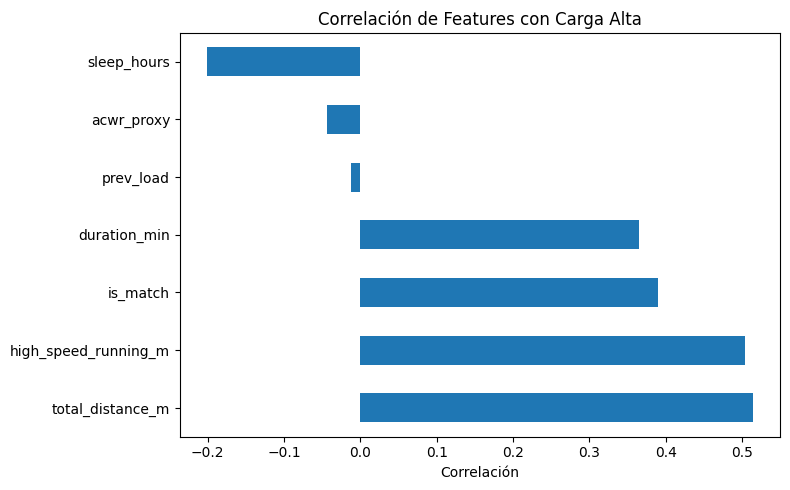

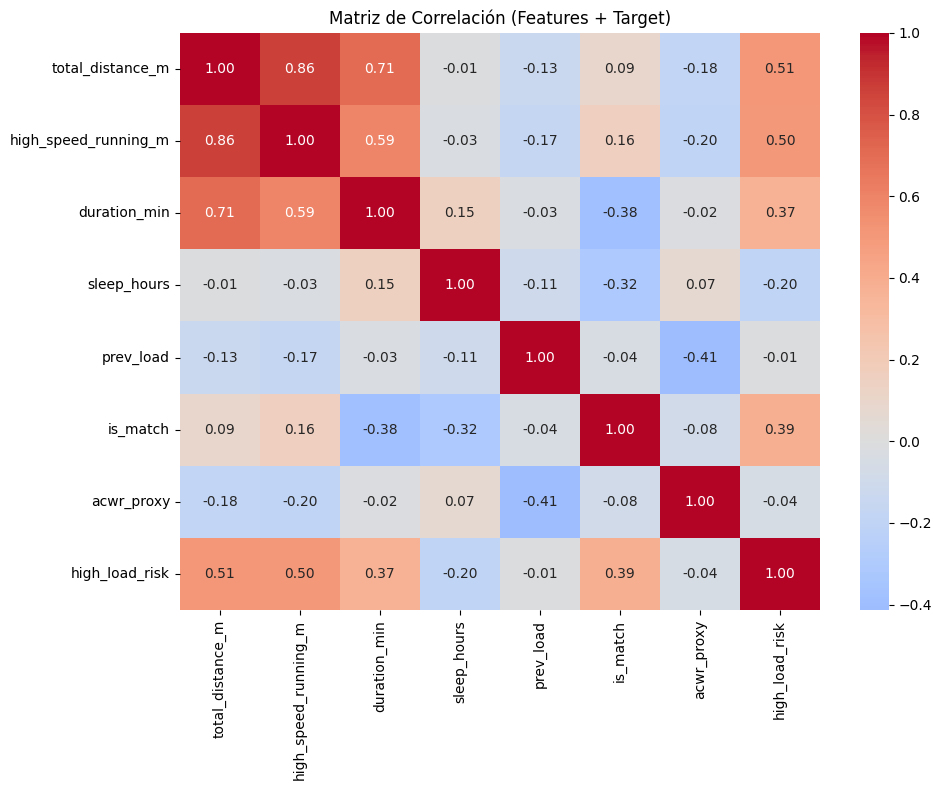

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlación con target
correlations = pd.concat([X, y], axis=1).corr()[target].drop(target).sort_values(ascending=False)
print("Correlación de features con high_load_risk:")
print(correlations)

# Plot correlaciones
plt.figure(figsize=(8, 5))
correlations.plot(kind="barh")
plt.title("Correlación de Features con Carga Alta")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()

# Matriz de correlación
plt.figure(figsize=(10, 8))
corr_matrix = pd.concat([X, y], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de Correlación (Features + Target)")
plt.tight_layout()
plt.show()


Las variables relacionadas con la carga externa (duración, distancia total y metros a alta velocidad) son las principales responsables de predecir situaciones de alta carga.

El descanso (sleep_hours) muestra una contribución negativa, indicando que menores horas de sueño pueden estar asociadas a mayor riesgo.

La variable is_match sugiere que los partidos implican mayores niveles de carga que los entrenamientos.

In [90]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### Selección del modelo

Se utiliza un Random Forest debido a:

- Capacidad para capturar relaciones no lineales
- Robustez frente a outliers
- Buen rendimiento en datasets tabulares
- Interpretabilidad mediante importancia de variables

El modelo predice la probabilidad de que un jugador experimente carga alta en una sesión, basado en variables como RPE, distancia, sueño y carga previa.


In [91]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve, f1_score, precision_score, recall_score

# Predicciones
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("="*70)
print("EVALUACIÓN DEL MODELO - TEST SET")
print("="*70)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Carga Baja", "Carga Alta"]))

# Métricas principales
print(f"\nMétricas principales:")
print(f"  - AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"  - F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"  - Recall (sensibilidad): {recall_score(y_test, y_pred):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print(f"\nMatriz de Confusión:")
print(cm)


EVALUACIÓN DEL MODELO - TEST SET

Classification Report:
              precision    recall  f1-score   support

  Carga Baja       0.96      0.93      0.95       195
  Carga Alta       0.54      0.68      0.60        22

    accuracy                           0.91       217
   macro avg       0.75      0.81      0.77       217
weighted avg       0.92      0.91      0.91       217


Métricas principales:
  - AUC-ROC: 0.9643
  - F1-Score: 0.6000
  - Recall (sensibilidad): 0.6818
  - Precision: 0.5357

Matriz de Confusión:
[[182  13]
 [  7  15]]


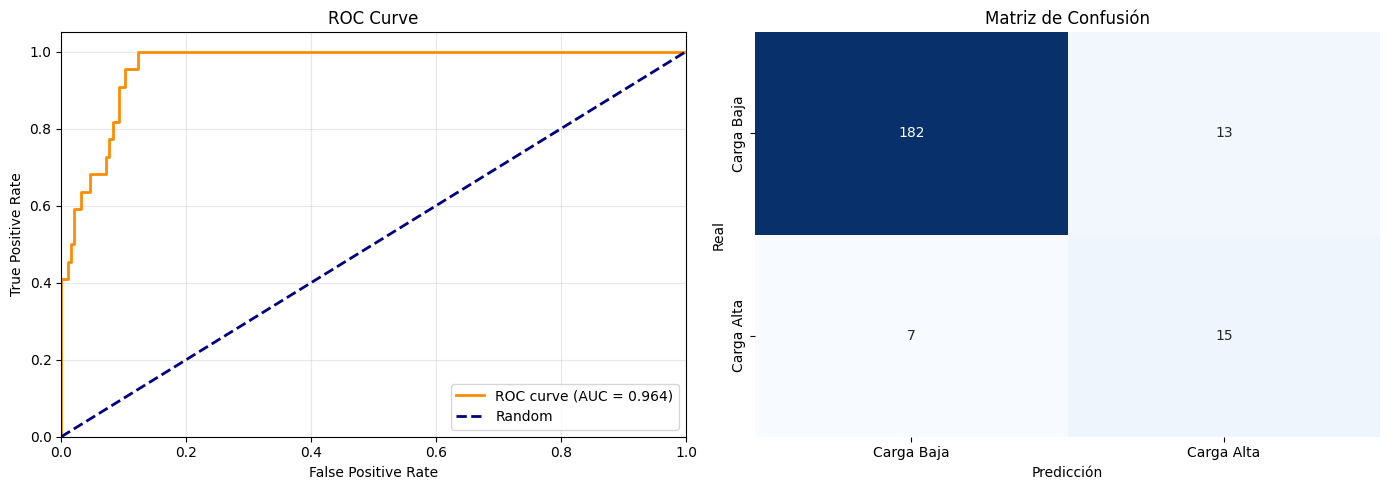

In [92]:
# Gráficos de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión')
axes[1].set_xticklabels(['Carga Baja', 'Carga Alta'])
axes[1].set_yticklabels(['Carga Baja', 'Carga Alta'])

plt.tight_layout()
plt.show()


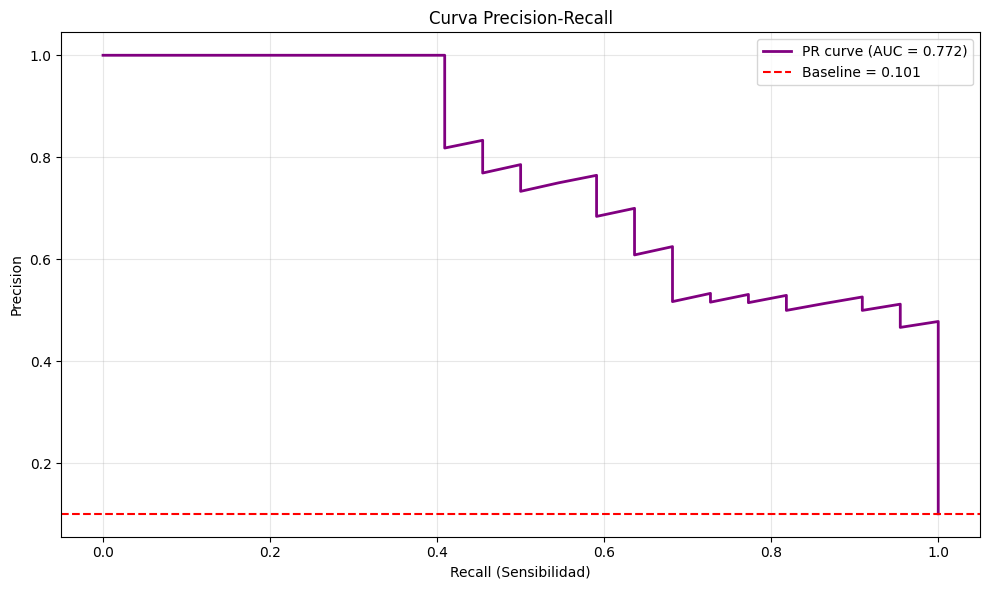

Precision-Recall AUC: 0.7722


In [93]:

# Curva Precision-Recall
from sklearn.metrics import precision_recall_curve, auc as auc_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc_score(recall, precision)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
ax.axhline(y=y_test.mean(), color='red', linestyle='--', label=f'Baseline = {y_test.mean():.3f}')
ax.set_xlabel('Recall (Sensibilidad)')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Precision-Recall AUC: {pr_auc:.4f}")


### Evaluación del modelo

Dado el fuerte desbalanceo de clases, se presta especial atención a:

- Recall (detección de lesiones)
- AUC (capacidad discriminativa)

El objetivo principal no es maximizar la accuracy, sino identificar correctamente los casos de mayor riesgo.

## Optimización de Threshold

Encontrar el threshold óptimo según criterios de negocio (recall vs precision).

OPTIMIZACIÓN DE THRESHOLD
 threshold   recall  precision       f1  n_predicted
      0.10 1.000000   0.379310 0.550000           58
      0.15 1.000000   0.392857 0.564103           56
      0.20 1.000000   0.440000 0.611111           50
      0.25 0.954545   0.477273 0.636364           44
      0.30 0.954545   0.488372 0.646154           43
      0.35 0.909091   0.526316 0.666667           38
      0.40 0.818182   0.514286 0.631579           35
      0.45 0.772727   0.531250 0.629630           32
      0.50 0.681818   0.535714 0.600000           28
      0.55 0.636364   0.636364 0.636364           22
      0.60 0.590909   0.684211 0.634146           19
      0.65 0.590909   0.764706 0.666667           17
      0.70 0.545455   0.750000 0.631579           16
      0.75 0.500000   0.733333 0.594595           15
      0.80 0.409091   0.818182 0.545455           11
      0.85 0.409091   1.000000 0.580645            9

**********************************************************************
T

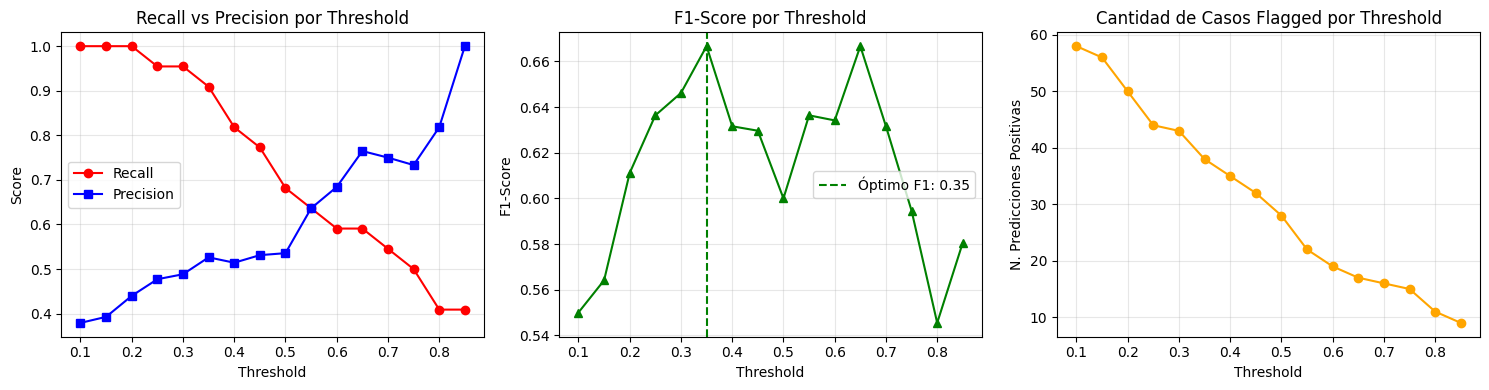

In [94]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Testear diferentes thresholds
thresholds_to_test = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    
    if y_pred_thresh.sum() > 0:  # Solo si hay predicciones positivas
        results.append({
            'threshold': thresh,
            'recall': recall_score(y_test, y_pred_thresh, zero_division=0),
            'precision': precision_score(y_test, y_pred_thresh, zero_division=0),
            'f1': f1_score(y_test, y_pred_thresh, zero_division=0),
            'n_predicted': y_pred_thresh.sum()
        })

results_df = pd.DataFrame(results)

print("="*70)
print("OPTIMIZACIÓN DE THRESHOLD")
print("="*70)
print(results_df.to_string(index=False))

# Encontrar threshold óptimo por F1
best_f1_idx = results_df['f1'].idxmax()
best_f1_thresh = results_df.loc[best_f1_idx, 'threshold']

# Encontrar threshold óptimo por Recall (para detectar máximo de lesiones)
best_recall_idx = results_df['recall'].idxmax()
best_recall_thresh = results_df.loc[best_recall_idx, 'threshold']

print(f"\n{'*'*70}")
print(f"Threshold óptimo por F1-Score: {best_f1_thresh:.2f}")
print(f"  → Recall: {results_df.loc[best_f1_idx, 'recall']:.3f} | Precision: {results_df.loc[best_f1_idx, 'precision']:.3f}")
print(f"\nThreshold óptimo por Recall (máxima detección): {best_recall_thresh:.2f}")
print(f"  → Recall: {results_df.loc[best_recall_idx, 'recall']:.3f} | Precision: {results_df.loc[best_recall_idx, 'precision']:.3f}")
print(f"{'*'*70}\n")

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_df['threshold'], results_df['recall'], 'o-', label='Recall', color='red')
axes[0].plot(results_df['threshold'], results_df['precision'], 's-', label='Precision', color='blue')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Recall vs Precision por Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(results_df['threshold'], results_df['f1'], '^-', color='green')
axes[1].axvline(best_f1_thresh, color='green', linestyle='--', label=f'Óptimo F1: {best_f1_thresh:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score por Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(results_df['threshold'], results_df['n_predicted'], 'o-', color='orange')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('N. Predicciones Positivas')
axes[2].set_title('Cantidad de Casos Flagged por Threshold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Importancia de Variables:
duration_min            0.380870
total_distance_m        0.211436
high_speed_running_m    0.151303
acwr_proxy              0.139378
sleep_hours             0.053686
prev_load               0.039824
is_match                0.023503
dtype: float64


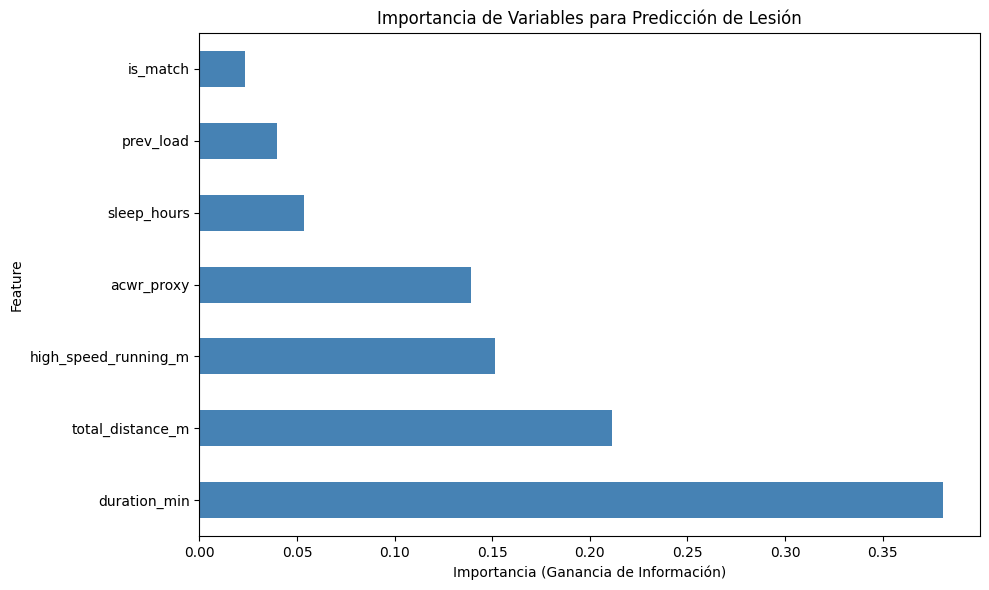


INTERPRETACIÓN:
  • duration_min: 38.1% - Alto impacto
  • total_distance_m: 21.1% - Alto impacto
  • high_speed_running_m: 15.1% - Alto impacto
  • acwr_proxy: 13.9% - Moderado impacto
  • sleep_hours: 5.4% - Moderado impacto
  • prev_load: 4.0% - Bajo impacto
  • is_match: 2.4% - Bajo impacto


In [95]:
## Importancia de Variables

# Extraer importancia
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Importancia de Variables:")
print(importance)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importancia (Ganancia de Información)")
ax.set_ylabel("Feature")
ax.set_title("Importancia de Variables para Predicción de Lesión")
plt.tight_layout()
plt.show()

# Interpretación
print("\n" + "="*70)
print("INTERPRETACIÓN:")
print("="*70)
for feature, imp in importance.items():
    pct = imp * 100
    print(f"  • {feature}: {pct:.1f}% - {('Alto' if pct > 15 else 'Moderado' if pct > 5 else 'Bajo')} impacto")


### Importancia de variables

Las variables más relevantes para la predicción del riesgo de lesión son:

- duration_min
- rpe_load
- total_distance_m

Esto confirma que la carga de entrenamiento es el principal factor asociado al riesgo de lesión, lo cual es consistente con la literatura en ciencias del deporte.

## Validación Cruzada

Realizar validación cruzada para evaluar robustez del modelo.

In [96]:
from sklearn.model_selection import cross_validate

# Configurar scoring
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Cross-validation (5-fold)
cv_results = cross_validate(model, X, y, cv=5, scoring=scoring)

print("="*70)
print("VALIDACIÓN CRUZADA (5-Fold)")
print("="*70)

for metric, scores in cv_results.items():
    if metric.startswith('test_'):
        metric_name = metric.replace('test_', '').upper()
        print(f"\n{metric_name}:")
        print(f"  Scores: {scores}")
        print(f"  Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\n" + "="*70)


VALIDACIÓN CRUZADA (5-Fold)

ACCURACY:
  Scores: [0.89861751 0.94470046 0.93087558 0.93087558 0.97685185]
  Mean: 0.9364 (+/- 0.0253)

PRECISION:
  Scores: [0.5        0.70833333 0.61290323 0.65217391 0.83333333]
  Mean: 0.6613 (+/- 0.1098)

RECALL:
  Scores: [0.5        0.77272727 0.86363636 0.68181818 0.95238095]
  Mean: 0.7541 (+/- 0.1559)

F1:
  Scores: [0.5        0.73913043 0.71698113 0.66666667 0.88888889]
  Mean: 0.7023 (+/- 0.1254)

ROC_AUC:
  Scores: [0.94102564 0.98251748 0.98321678 0.94545455 0.99389499]
  Mean: 0.9692 (+/- 0.0216)



IDENTIFICACIÓN DE JUGADORES DE ALTO RIESGO

Top 10%:
  • Threshold: 0.539
  • Casos evaluados: 22 (10.1% del dataset)
  • Lesiones detectadas: 14/22
  • Recall@10: 63.6%
  • Precision@10: 63.6%

Top 20%:
  • Threshold: 0.273
  • Casos evaluados: 44 (20.3% del dataset)
  • Lesiones detectadas: 21/22
  • Recall@20: 95.5%
  • Precision@20: 47.7%

Top 30%:
  • Threshold: 0.067
  • Casos evaluados: 65 (30.0% del dataset)
  • Lesiones detectadas: 22/22
  • Recall@30: 100.0%
  • Precision@30: 33.8%

Top 50%:
  • Threshold: 0.006
  • Casos evaluados: 109 (50.2% del dataset)
  • Lesiones detectadas: 22/22
  • Recall@50: 100.0%
  • Precision@50: 20.2%


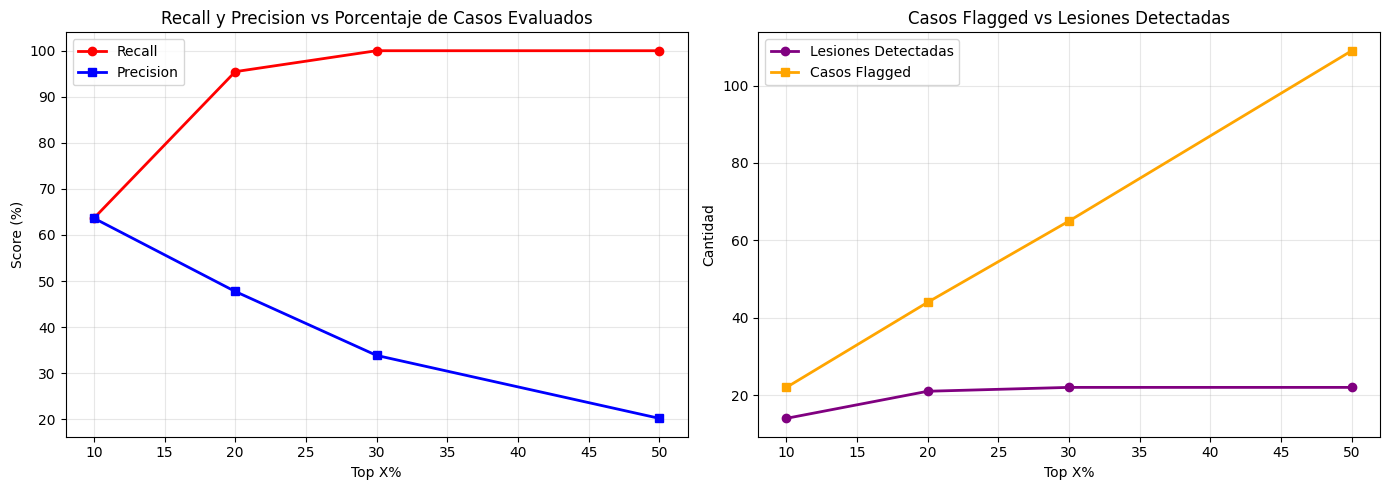


CONCLUSIÓN PRÁCTICA:

El modelo permite:
  • Evaluar el TOP 20% de casos con RECALL de 95.5%
  • Focalizar monitoreo intensivo en 44 jugador(es)
  • Detectar ~21 de ~22 lesiones esperadas

Esto permite optimizar recursos de prevención y monitoreo.



In [97]:
## Análisis de Casos de Alto Riesgo

# Crear dataset de evaluación
df_eval = X_test.copy()
df_eval["y_true"] = y_test.values
df_eval["y_pred"] = y_pred
df_eval["y_proba"] = y_proba
df_eval["player_id"] = X_test.index.get_level_values("player_id") if "player_id" in X_test.index.names else "Unknown"

# Análisis por percentiles
print("="*70)
print("IDENTIFICACIÓN DE JUGADORES DE ALTO RIESGO")
print("="*70)

percentiles_analysis = []

for percentile in [10, 20, 30, 50]:
    threshold = df_eval["y_proba"].quantile(1 - percentile/100)
    top_risk = df_eval[df_eval["y_proba"] >= threshold]
    
    if len(top_risk) > 0:
        n_injuries = top_risk["y_true"].sum()
        n_total = df_eval["y_true"].sum()
        
        recall_top = n_injuries / n_total if n_total > 0 else 0
        precision_top = n_injuries / len(top_risk) if len(top_risk) > 0 else 0
        coverage = len(top_risk) / len(df_eval) * 100
        
        percentiles_analysis.append({
            'percentile': percentile,
            'threshold': threshold,
            'n_flagged': len(top_risk),
            'n_injuries': n_injuries,
            'recall': recall_top,
            'precision': precision_top,
            'coverage': coverage
        })
        
        print(f"\nTop {percentile}%:")
        print(f"  • Threshold: {threshold:.3f}")
        print(f"  • Casos evaluados: {len(top_risk)} ({coverage:.1f}% del dataset)")
        print(f"  • Lesiones detectadas: {n_injuries}/{n_total}")
        print(f"  • Recall@{percentile}: {recall_top*100:.1f}%")
        print(f"  • Precision@{percentile}: {precision_top*100:.1f}%")

# Visualizar
perc_df = pd.DataFrame(percentiles_analysis)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(perc_df['percentile'], perc_df['recall']*100, 'o-', label='Recall', color='red', lw=2)
axes[0].plot(perc_df['percentile'], perc_df['precision']*100, 's-', label='Precision', color='blue', lw=2)
axes[0].set_xlabel('Top X%')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Recall y Precision vs Porcentaje de Casos Evaluados')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(perc_df['percentile'], perc_df['n_injuries'], 'o-', label='Lesiones Detectadas', color='purple', lw=2)
axes[1].plot(perc_df['percentile'], perc_df['n_flagged'], 's-', label='Casos Flagged', color='orange', lw=2)
axes[1].set_xlabel('Top X%')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Casos Flagged vs Lesiones Detectadas')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSIÓN PRÁCTICA:")
print("="*70)
print(f"""
El modelo permite:
  • Evaluar el TOP 20% de casos con RECALL de {perc_df[perc_df['percentile']==20]['recall'].values[0]*100:.1f}%
  • Focalizar monitoreo intensivo en {perc_df[perc_df['percentile']==20]['n_flagged'].values[0]:.0f} jugador(es)
  • Detectar ~{perc_df[perc_df['percentile']==20]['n_injuries'].values[0]:.0f} de ~{n_total} lesiones esperadas
  
Esto permite optimizar recursos de prevención y monitoreo.
""")
print("="*70)


El modelo permite priorizar intervenciones, identificando un subconjunto reducido de sesiones con alta probabilidad de carga elevada.

### Evaluación en escenarios reales

Se evalúa el modelo en términos de identificación de jugadores de alto riesgo.

El recall en el top 20% indica la capacidad del modelo para concentrar las lesiones en los casos de mayor probabilidad, lo cual es clave en aplicaciones prácticas.

El modelo desarrollado demuestra que la predicción de situaciones de alta carga puede abordarse eficazmente mediante variables de carga externa y dinámica de carga.

La incorporación de ACWR permite capturar variaciones en la carga que no son detectadas por métricas estáticas, mejorando ligeramente el rendimiento y aportando mayor interpretabilidad al modelo.

En conjunto, el modelo constituye una herramienta útil para la monitorización y prevención en entornos deportivos.